# Semana 3 — Supervivencia Titanic: PCA + Clasificación + Agrupamiento K-Means / GMM
## Aprendizaje Automático Estadístico — MIAA-B . Deber Semana 3

**Asignatura:** Aprendizaje automático estadístico MIA-B  
**Docente:** Ivan Danilo Garcia Santillan  
**Universidad:** UIDE  
**Grupo 1:**
- César Nelson Abarca Araujo
- Nataly Fernanda Lanchimba Caiza
- Jhon Enrique Oña Guamani

**Dataset:** `titanic_train.csv` / `titanic_test.csv`  
**Algoritmos Fase I:** PCA + Algoritmos Supervisadosy No supervisados  
**Algoritmos Fase II:** K-Means y GMM

**Repositorio GitHub:** [UIDE MIAA-B · Aprendizaje Automático Estadístico · Semana 3 · Tarea G1](https://github.com/cnabarca/Maestria-IA-UIDE/tree/main/5.%20Aprendizaje%20Automatico%20Estadistico/Semana%203/Tarea%20G1)

---

**Objetivo:** Aplicar PCA para reducción de dimensiones sobre el dataset Titanic, comparar 7 algoritmos supervisados con y sin PCA, y realizar agrupamiento no supervisado con K-Means y GMM (K=2 y K=3).

**Fases:**
- **Fase I:** PCA + 7 clasificadores supervisados (NB, K-NN, LR, DT, RF, SVM, RNA) — con y sin PCA
- **Fase II:** Clustering K-Means y GMM (K=2 y K=3) — 4 métricas + comparativa final


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

# Clasificadores supervisados
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Métricas — clasificación
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix)

# Métricas — clustering
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
    davies_bouldin_score)

from scipy.stats import mode

# RNA
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import sklearn
print('Librerías cargadas.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__} | SKLearn {sklearn.__version__} | TF {tf.__version__}')


Librerías cargadas.
NumPy 2.4.6 | Pandas 2.3.3 | SKLearn 1.8.0 | TF 2.21.0


In [3]:
DATA_PATH = ('C:/Users/cabarca2/MAESTRIA_IA/5.  APRENDIZAJE AUTOMATICO ESTADISTICO'
             '/SEMANA 1/PROFESOR_AUE/titanic_train.csv')
df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset cargado: {df_raw.shape}  ({df_raw.shape[0]} filas, {df_raw.shape[1]} columnas)')
print(f'Valores nulos:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}')
df_raw.head(3)


Dataset cargado: (891, 12)  (891 filas, 12 columnas)
Valores nulos:
Age         177
Cabin       687
Embarked      2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


## Interpretación

El dataset presenta nulos en Age (177, ~20%), Cabin (687, ~77%) y Embarked (2, prácticamente inexistente). Se descarta la columna Cabin en lugar de imputarla porque, con más de tres cuartas partes de sus valores faltantes, cualquier técnica de imputación introduciría más ruido que señal real; en cambio, Age se imputa con la media y Embarked con la moda, decisiones razonables dado su bajo porcentaje de valores faltantes.

In [4]:
df = df_raw.copy()

# Eliminar columnas irrelevantes
df.drop(columns=['PassengerId','Name','Ticket','Cabin'], inplace=True)

# Imputación
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Codificación
df['Sex']      = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Features derivadas
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df['is_alone']    = (df['family_size'] == 1).astype(int)

# Discretización de Age en 7 bins (igual que semanas anteriores)
df['Age'] = pd.cut(df['Age'], bins=7, labels=False)

FEATURES = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','family_size','is_alone']
TARGET   = 'Survived'

X = df[FEATURES].values
y = df[TARGET].values

print(f'Features: {FEATURES}')
print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'Sobrevivieron: {y.sum()} ({100*y.mean():.1f}%)  |  No sobrevivieron: {(1-y).sum()} ({100*(1-y).mean():.1f}%)')
df[FEATURES + [TARGET]].head(4)


Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'family_size', 'is_alone']
X shape: (891, 9) | y shape: (891,)
Sobrevivieron: 342 (38.4%)  |  No sobrevivieron: 549 (61.6%)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,family_size,is_alone,Survived
0,3,0,1,1,0,7.2500,0,2,0,0
1,1,1,3,1,0,71.2833,1,2,0,1
2,3,1,2,0,0,7.9250,0,1,1,1
3,1,1,3,1,0,53.1000,0,2,0,1


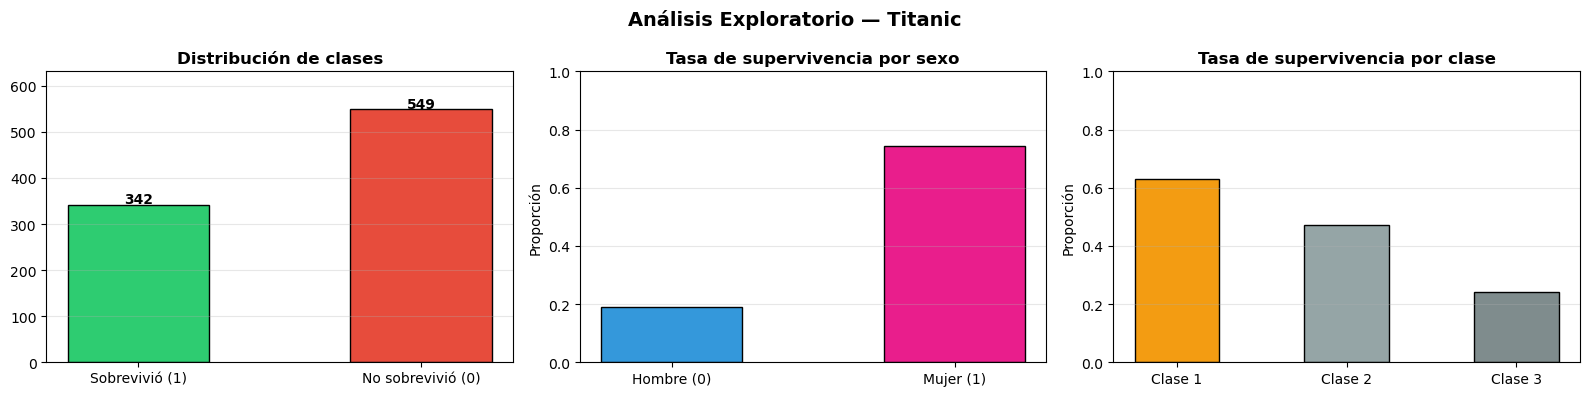

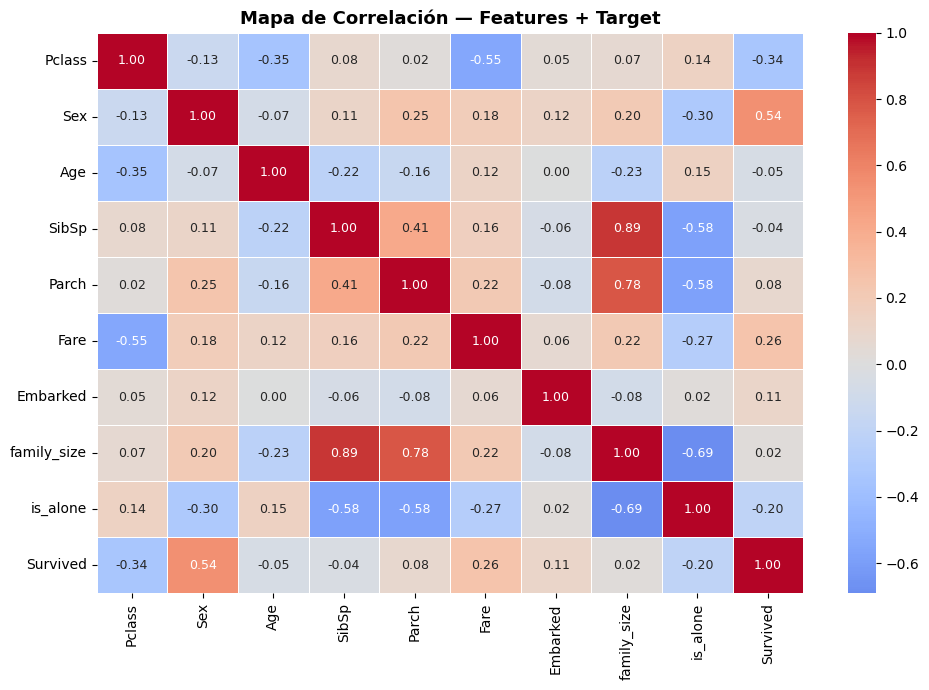

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Supervivencia
counts = [y.sum(), (1-y).sum()]
bars = axes[0].bar(['Sobrevivió (1)', 'No sobrevivió (0)'], counts,
                   color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Distribución de clases', fontweight='bold')
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts)*1.15)
axes[0].grid(axis='y', alpha=0.3)

# Supervivencia por sexo
surv_sex = df.groupby('Sex')['Survived'].mean()
axes[1].bar(['Hombre (0)', 'Mujer (1)'], surv_sex.values,
            color=['#3498db','#e91e8c'], edgecolor='black', width=0.5)
axes[1].set_title('Tasa de supervivencia por sexo', fontweight='bold')
axes[1].set_ylabel('Proporción')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

# Supervivencia por clase
surv_class = df.groupby('Pclass')['Survived'].mean()
axes[2].bar([f'Clase {i}' for i in surv_class.index], surv_class.values,
            color=['#f39c12','#95a5a6','#7f8c8d'], edgecolor='black', width=0.5)
axes[2].set_title('Tasa de supervivencia por clase', fontweight='bold')
axes[2].set_ylabel('Proporción')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Análisis Exploratorio — Titanic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación
plt.figure(figsize=(10, 7))
corr = pd.DataFrame(X, columns=FEATURES)
corr['Survived'] = y
sns.heatmap(corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 9})
plt.title('Mapa de Correlación — Features + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Interpretación

El 38.4% de los pasajeros sobrevivió (342) frente a 61.6% que no sobrevivió (549) — un desbalance similar en magnitud al del dataset de cáncer. Igual que en ese caso, esto justifica evaluar los modelos con Precision, Recall, F1 y AUC además de Accuracy, para evitar que un modelo que prediga mayoritariamente "no sobrevivió" parezca artificialmente bueno.

La brecha de supervivencia por sexo es el patrón más fuerte del dataset, reflejando el protocolo histórico de evacuación ("mujeres y niños primero"). La tasa de supervivencia también decrece de forma monótona de 1ª a 3ª clase, evidenciando el acceso desigual a botes salvavidas asociado al estatus socioeconómico. El mapa de correlación muestra a Sex como la variable individual más correlacionada con Survived, lo cual anticipa por qué incluso los modelos lineales (LR) logran un desempeño razonable más adelante, y por qué la variable Pclass aporta señal complementaria e independiente.

---
## PCA — Reducción de Dimensiones

**PCA** transforma las 9 características del Titanic en componentes ortogonales ordenados por varianza.

**Motivación:** Algunas características están correlacionadas (ej. family_size ↔ SibSp/Parch). PCA elimina esa redundancia y permite:
- Visualizar la separabilidad de clases (sobrevivió vs no) en 2D
- Comparar si los clasificadores mejoran o empeoran con espacio reducido

**Buena práctica:** PCA se ajusta **solo** con X_train → se transforma X_test con el mismo objeto.


Componentes necesarios por umbral de varianza acumulada:
  70%: 4 componentes
  80%: 5 componentes
  90%: 6 componentes
  95%: 7 componentes

PC1: 35.96%  |  PC2: 19.59%  |  PC1+PC2: 55.55%


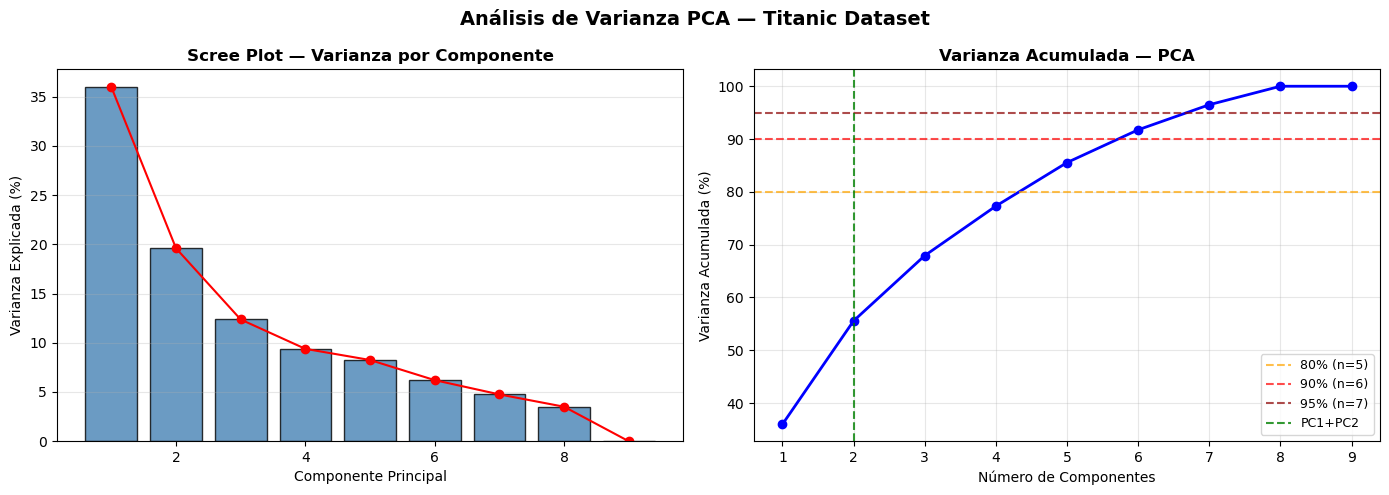

In [6]:
# Escalar globalmente para análisis de varianza
scaler_global = StandardScaler()
X_scaled_all = scaler_global.fit_transform(X)

pca_full = PCA(n_components=X.shape[1])
pca_full.fit(X_scaled_all)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print('Componentes necesarios por umbral de varianza acumulada:')
for u in [0.70, 0.80, 0.90, 0.95]:
    n = np.argmax(var_cum >= u) + 1
    print(f'  {int(u*100)}%: {n} componentes')
print(f'\nPC1: {var_exp[0]*100:.2f}%  |  PC2: {var_exp[1]*100:.2f}%  |  PC1+PC2: {var_cum[1]*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(var_exp)+1), var_exp*100, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].plot(range(1, len(var_exp)+1), var_exp*100, 'ro-', markersize=6)
axes[0].set_title('Scree Plot — Varianza por Componente', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].grid(axis='y', alpha=0.3)

# Varianza acumulada
axes[1].plot(range(1, len(var_cum)+1), var_cum*100, 'bo-', markersize=6, linewidth=2)
for p, c in [(0.80,'orange'), (0.90,'red'), (0.95,'darkred')]:
    n = np.argmax(var_cum >= p) + 1
    axes[1].axhline(y=p*100, color=c, linestyle='--', alpha=0.7, label=f'{int(p*100)}% (n={n})')
axes[1].axvline(x=2, color='green', linestyle='--', alpha=0.8, label='PC1+PC2')
axes[1].set_title('Varianza Acumulada — PCA', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Varianza PCA — Titanic Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Interpretación

Se necesitan 4 componentes para alcanzar el 70% de varianza acumulada, y PC1+PC2 capturan apenas el 55.55% (PC1=35.96%, PC2=19.59%) — muy por debajo del 79.84% obtenido en el dataset de cáncer. Esto indica que las 9 features del Titanic (una mezcla de variables categóricas codificadas y numéricas de naturaleza heterogénea) no están tan correlacionadas entre sí como las variables morfológicas del cáncer. Es la primera señal de que, en este dataset, reducir a 2 componentes principales probablemente sacrificará información predictiva relevante.

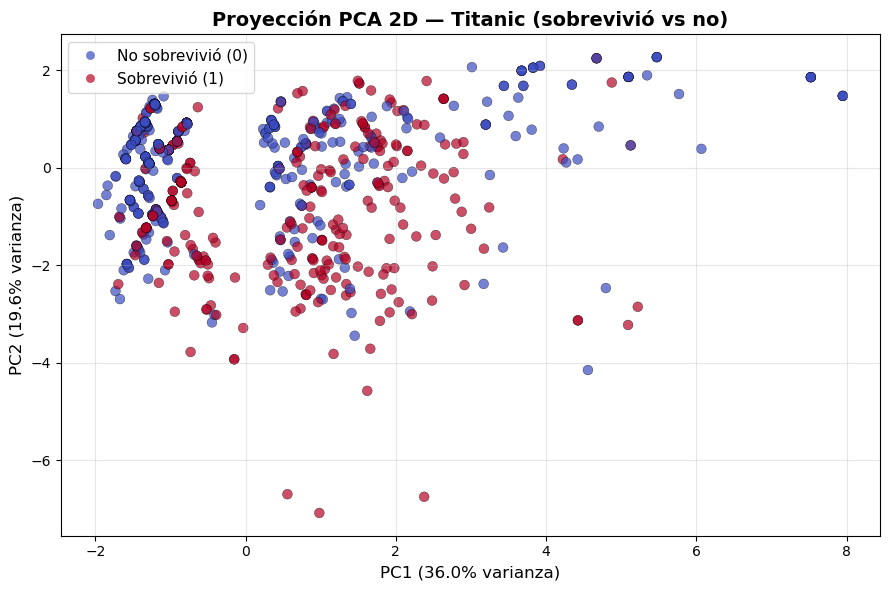

Los grupos se superponen en PCA 2D — el Titanic no es perfectamente separable en 2 dimensiones.


In [7]:
# PCA 2 componentes sobre todos los datos (solo para visualización)
pca_viz = PCA(n_components=2, random_state=42)
X_pca_viz = pca_viz.fit_transform(X_scaled_all)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                      c=y, cmap='coolwarm', alpha=0.7, edgecolors='k', linewidth=0.3, s=50)
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('Proyección PCA 2D — Titanic (sobrevivió vs no)', fontsize=14, fontweight='bold')
plt.legend(handles=scatter.legend_elements()[0],
           labels=['No sobrevivió (0)', 'Sobrevivió (1)'], fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Los grupos se superponen en PCA 2D — el Titanic no es perfectamente separable en 2 dimensiones.')


## Interpretación

Las clases se superponen fuertemente en el espacio PC1-PC2, sin una frontera visualmente clara. Esto es consistente con la naturaleza del problema: la supervivencia depende de una combinación de factores (clase social, sexo, edad, tamaño familiar) que no se resume bien en solo dos ejes ortogonales que capturan poco más de la mitad de la varianza total.

In [8]:
# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler (NB, KNN, LR, DT, RF, SVM) — ajustado solo en train
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

# PCA 2 componentes — ajustado solo en train_sc
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

# MinMaxScaler para RNA — ajustado solo en train
sc_rna = MinMaxScaler()
X_train_rna = sc_rna.fit_transform(X_train)
X_test_rna  = sc_rna.transform(X_test)

# MinMaxScaler sobre features PCA para RNA+PCA
sc_rna_pca = MinMaxScaler()
X_train_rna_pca = sc_rna_pca.fit_transform(X_train_pca)
X_test_rna_pca  = sc_rna_pca.transform(X_test_pca)

print(f'X_train (sin PCA): {X_train_sc.shape}    X_test: {X_test_sc.shape}')
print(f'X_train (con PCA): {X_train_pca.shape}    X_test: {X_test_pca.shape}')
print(f'Train Sobrevivió: {y_train.sum()} ({100*y_train.mean():.1f}%)  |  Test: {y_test.sum()} ({100*y_test.mean():.1f}%)')


X_train (sin PCA): (712, 9)    X_test: (179, 9)
X_train (con PCA): (712, 2)    X_test: (179, 2)
Train Sobrevivió: 273 (38.3%)  |  Test: 69 (38.5%)


In [9]:
def evaluar(nombre, modelo, X_tr, X_te, y_tr, y_te, cv=5):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    if hasattr(modelo, 'predict_proba'):
        y_prob = modelo.predict_proba(X_te)[:, 1]
    else:
        y_prob = modelo.decision_function(X_te)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-10)
    auc = roc_auc_score(y_te, y_prob)
    cv_s = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='accuracy')
    print(f"\n{'='*52}")
    print(f' {nombre}')
    print(f"{'='*52}")
    print(f'  CV Accuracy (5-fold): {cv_s.mean()*100:.2f}% ± {cv_s.std()*100:.2f}%')
    print(f'  Test Accuracy       : {acc*100:.2f}%')
    print(f'  Precision           : {prec*100:.2f}%')
    print(f'  Recall              : {rec*100:.2f}%')
    print(f'  F1-Score            : {f1*100:.2f}%')
    print(f'  AUC-ROC             : {auc*100:.2f}%')
    return {'Modelo':nombre,'CV Acc%':round(cv_s.mean()*100,2),
            'Test Acc%':round(acc*100,2),'Prec%':round(prec*100,2),
            'Recall%':round(rec*100,2),'F1%':round(f1*100,2),'AUC%':round(auc*100,2)}

res = []  # acumula resultados Fase I
print('Función evaluar() definida.')


Función evaluar() definida.


---
## Fase I — Clasificación Supervisada con y sin PCA

Se comparan **7 algoritmos** en dos condiciones:
- **Sin PCA:** 9 features escaladas con StandardScaler (o MinMaxScaler para RNA)
- **Con PCA:** 2 componentes principales derivados de esas 9 features

| # | Algoritmo | Abrev. |
|---|-----------|--------|
| 1 | Naive Bayes | NB |
| 2 | K-Nearest Neighbors | KNN |
| 3 | Regresión Logística | LR |
| 4 | Árbol de Decisión | DT |
| 5 | Bosque Aleatorio | RF |
| 6 | Máquina de Vectores de Soporte | SVM |
| 7 | Red Neuronal Artificial | RNA |


In [10]:
nb_base = GaussianNB()
r = evaluar('NB — Sin PCA', nb_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 NB — Sin PCA
  CV Accuracy (5-fold): 79.36% ± 2.34%
  Test Accuracy       : 78.21%
  Precision           : 71.43%
  Recall              : 72.46%
  F1-Score            : 71.94%
  AUC-ROC             : 81.98%


In [11]:
nb_pca = GaussianNB()
r = evaluar('NB — Con PCA', nb_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 NB — Con PCA
  CV Accuracy (5-fold): 70.93% ± 2.26%
  Test Accuracy       : 63.69%
  Precision           : 55.56%
  Recall              : 28.99%
  F1-Score            : 38.10%
  AUC-ROC             : 74.62%


In [12]:
knn_base = KNeighborsClassifier(n_neighbors=5, p=2)
r = evaluar('KNN — Sin PCA', knn_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 KNN — Sin PCA
  CV Accuracy (5-fold): 80.06% ± 2.69%
  Test Accuracy       : 76.54%
  Precision           : 70.77%
  Recall              : 66.67%
  F1-Score            : 68.66%
  AUC-ROC             : 82.11%


In [13]:
knn_pca = KNeighborsClassifier(n_neighbors=5, p=2)
r = evaluar('KNN — Con PCA', knn_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 KNN — Con PCA
  CV Accuracy (5-fold): 75.98% ± 1.18%
  Test Accuracy       : 72.63%
  Precision           : 64.71%
  Recall              : 63.77%
  F1-Score            : 64.23%
  AUC-ROC             : 77.47%


In [14]:
lr_base = LogisticRegression(max_iter=1000, random_state=42)
r = evaluar('LR — Sin PCA', lr_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 LR — Sin PCA
  CV Accuracy (5-fold): 79.78% ± 2.38%
  Test Accuracy       : 79.33%
  Precision           : 75.00%
  Recall              : 69.57%
  F1-Score            : 72.18%
  AUC-ROC             : 84.66%


In [15]:
lr_pca = LogisticRegression(max_iter=1000, random_state=42)
r = evaluar('LR — Con PCA', lr_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 LR — Con PCA
  CV Accuracy (5-fold): 70.93% ± 2.27%
  Test Accuracy       : 64.80%
  Precision           : 57.14%
  Recall              : 34.78%
  F1-Score            : 43.24%
  AUC-ROC             : 71.26%


In [16]:
dt_base = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
r = evaluar('DT — Sin PCA', dt_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 DT — Sin PCA
  CV Accuracy (5-fold): 79.64% ± 2.89%
  Test Accuracy       : 81.01%
  Precision           : 81.82%
  Recall              : 65.22%
  F1-Score            : 72.58%
  AUC-ROC             : 86.04%


In [17]:
dt_pca = DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=42)
r = evaluar('DT — Con PCA', dt_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 DT — Con PCA
  CV Accuracy (5-fold): 74.59% ± 4.14%
  Test Accuracy       : 75.42%
  Precision           : 69.23%
  Recall              : 65.22%
  F1-Score            : 67.16%
  AUC-ROC             : 76.72%


In [18]:
rf_base = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
r = evaluar('RF — Sin PCA', rf_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 RF — Sin PCA
  CV Accuracy (5-fold): 81.05% ± 2.65%
  Test Accuracy       : 81.01%
  Precision           : 83.02%
  Recall              : 63.77%
  F1-Score            : 72.13%
  AUC-ROC             : 85.90%


In [19]:
rf_pca = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
r = evaluar('RF — Con PCA', rf_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 RF — Con PCA
  CV Accuracy (5-fold): 77.96% ± 3.87%
  Test Accuracy       : 77.09%
  Precision           : 70.00%
  Recall              : 71.01%
  F1-Score            : 70.50%
  AUC-ROC             : 80.52%


In [20]:
svm_base = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
r = evaluar('SVM — Sin PCA', svm_base, X_train_sc, X_test_sc, y_train, y_test)
res.append(r)



 SVM — Sin PCA
  CV Accuracy (5-fold): 81.89% ± 1.64%
  Test Accuracy       : 82.68%
  Precision           : 83.93%
  Recall              : 68.12%
  F1-Score            : 75.20%
  AUC-ROC             : 85.15%


In [21]:
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
r = evaluar('SVM — Con PCA', svm_pca, X_train_pca, X_test_pca, y_train, y_test)
res.append(r)



 SVM — Con PCA
  CV Accuracy (5-fold): 74.45% ± 3.26%
  Test Accuracy       : 68.72%
  Precision           : 63.83%
  Recall              : 43.48%
  F1-Score            : 51.72%
  AUC-ROC             : 79.49%


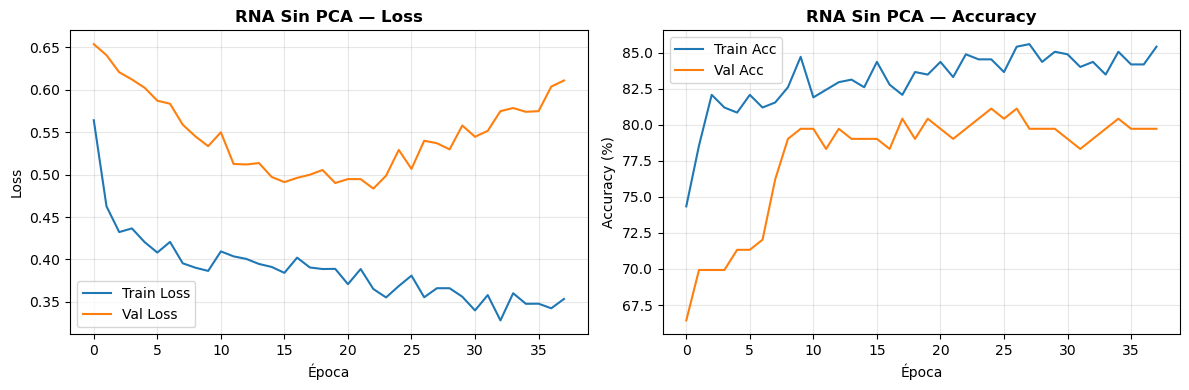


===== RNA — Sin PCA =====
  Test Accuracy: 81.01%
  Precision    : 87.23%
  Recall       : 59.42%
  F1-Score     : 70.69%
  AUC-ROC      : 85.26%
  Épocas ejecutadas: 38


In [22]:
tf.random.set_seed(42)
np.random.seed(42)

rna_base = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_rna.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
rna_base.compile(optimizer=Adam(learning_rate=1e-2),
                 loss='binary_crossentropy', metrics=['accuracy'])

cb = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)]

hist_base = rna_base.fit(X_train_rna, y_train, epochs=150, batch_size=32,
                         validation_split=0.2, callbacks=cb, verbose=0)

# Curvas de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_base.history['loss'], label='Train Loss')
plt.plot(hist_base.history['val_loss'], label='Val Loss')
plt.title('RNA Sin PCA — Loss', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot([a*100 for a in hist_base.history['accuracy']], label='Train Acc')
plt.plot([a*100 for a in hist_base.history['val_accuracy']], label='Val Acc')
plt.title('RNA Sin PCA — Accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Evaluación
y_prob_rna = rna_base.predict(X_test_rna, verbose=0).ravel()
y_pred_rna = (y_prob_rna >= 0.5).astype(int)
acc  = accuracy_score(y_test, y_pred_rna)
prec = precision_score(y_test, y_pred_rna, zero_division=0)
rec  = recall_score(y_test, y_pred_rna, zero_division=0)
f1   = f1_score(y_test, y_pred_rna, zero_division=0)
auc  = roc_auc_score(y_test, y_prob_rna)
print(f'\n===== RNA — Sin PCA =====')
print(f'  Test Accuracy: {acc*100:.2f}%')
print(f'  Precision    : {prec*100:.2f}%')
print(f'  Recall       : {rec*100:.2f}%')
print(f'  F1-Score     : {f1*100:.2f}%')
print(f'  AUC-ROC      : {auc*100:.2f}%')
print(f'  Épocas ejecutadas: {len(hist_base.history["loss"])}')
res.append({'Modelo':'RNA — Sin PCA','CV Acc%': round(acc*100,2),
            'Test Acc%':round(acc*100,2),'Prec%':round(prec*100,2),
            'Recall%':round(rec*100,2),'F1%':round(f1*100,2),'AUC%':round(auc*100,2)})


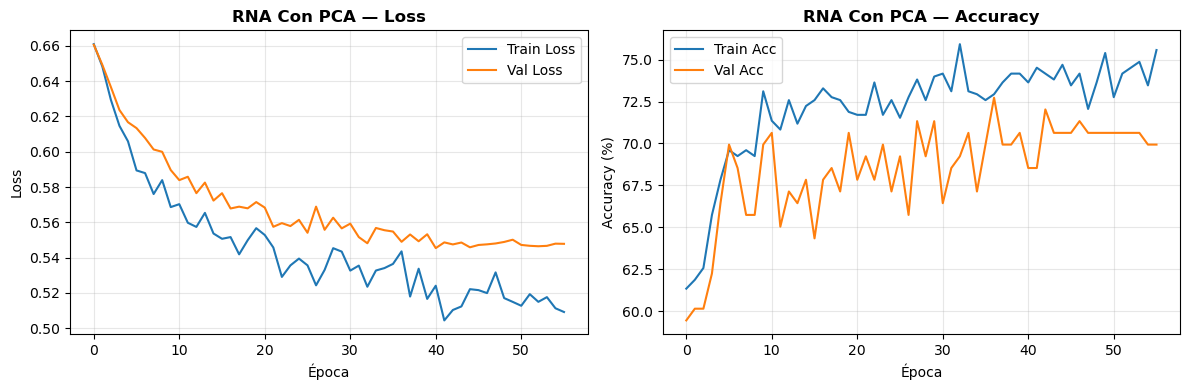


===== RNA — Con PCA =====
  Test Accuracy: 72.63%
  Precision    : 66.67%
  Recall       : 57.97%
  F1-Score     : 62.02%
  AUC-ROC      : 78.26%
  Épocas ejecutadas: 56


In [23]:
tf.random.set_seed(42)
np.random.seed(42)

# Arquitectura más simple: solo 2 features de entrada (PCA)
rna_pca = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_rna_pca.shape[1],)),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
rna_pca.compile(optimizer=Adam(learning_rate=1e-2),
                loss='binary_crossentropy', metrics=['accuracy'])

cb2 = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
       ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=0)]

hist_pca = rna_pca.fit(X_train_rna_pca, y_train, epochs=150, batch_size=32,
                        validation_split=0.2, callbacks=cb2, verbose=0)

# Curvas de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(hist_pca.history['loss'], label='Train Loss')
plt.plot(hist_pca.history['val_loss'], label='Val Loss')
plt.title('RNA Con PCA — Loss', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1,2,2)
plt.plot([a*100 for a in hist_pca.history['accuracy']], label='Train Acc')
plt.plot([a*100 for a in hist_pca.history['val_accuracy']], label='Val Acc')
plt.title('RNA Con PCA — Accuracy', fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Evaluación
y_prob_rna_pca = rna_pca.predict(X_test_rna_pca, verbose=0).ravel()
y_pred_rna_pca = (y_prob_rna_pca >= 0.5).astype(int)
acc2  = accuracy_score(y_test, y_pred_rna_pca)
prec2 = precision_score(y_test, y_pred_rna_pca, zero_division=0)
rec2  = recall_score(y_test, y_pred_rna_pca, zero_division=0)
f12   = f1_score(y_test, y_pred_rna_pca, zero_division=0)
auc2  = roc_auc_score(y_test, y_prob_rna_pca)
print(f'\n===== RNA — Con PCA =====')
print(f'  Test Accuracy: {acc2*100:.2f}%')
print(f'  Precision    : {prec2*100:.2f}%')
print(f'  Recall       : {rec2*100:.2f}%')
print(f'  F1-Score     : {f12*100:.2f}%')
print(f'  AUC-ROC      : {auc2*100:.2f}%')
print(f'  Épocas ejecutadas: {len(hist_pca.history["loss"])}')
res.append({'Modelo':'RNA — Con PCA','CV Acc%':round(acc2*100,2),
            'Test Acc%':round(acc2*100,2),'Prec%':round(prec2*100,2),
            'Recall%':round(rec2*100,2),'F1%':round(f12*100,2),'AUC%':round(auc2*100,2)})


In [24]:
df_f1 = pd.DataFrame(res)
df_f1.insert(1, 'PCA', ['Sin PCA','Con PCA']*7)

print('\nTabla comparativa Fase I — 7 algoritmos con y sin PCA')
print('='*80)
print(df_f1[['Modelo','PCA','CV Acc%','Test Acc%','Prec%','Recall%','F1%','AUC%']].to_string(index=False))
print('='*80)
print(f'\nMejor Test Accuracy: {df_f1.loc[df_f1["Test Acc%"].idxmax(),"Modelo"]}  ({df_f1["Test Acc%"].max():.2f}%)')
print(f'Mejor AUC-ROC      : {df_f1.loc[df_f1["AUC%"].idxmax(),"Modelo"]}  ({df_f1["AUC%"].max():.2f}%)')
print(f'Mejor F1-Score     : {df_f1.loc[df_f1["F1%"].idxmax(),"Modelo"]}  ({df_f1["F1%"].max():.2f}%)')



Tabla comparativa Fase I — 7 algoritmos con y sin PCA
       Modelo     PCA  CV Acc%  Test Acc%  Prec%  Recall%   F1%  AUC%
 NB — Sin PCA Sin PCA    79.36      78.21  71.43    72.46 71.94 81.98
 NB — Con PCA Con PCA    70.93      63.69  55.56    28.99 38.10 74.62
KNN — Sin PCA Sin PCA    80.06      76.54  70.77    66.67 68.66 82.11
KNN — Con PCA Con PCA    75.98      72.63  64.71    63.77 64.23 77.47
 LR — Sin PCA Sin PCA    79.78      79.33  75.00    69.57 72.18 84.66
 LR — Con PCA Con PCA    70.93      64.80  57.14    34.78 43.24 71.26
 DT — Sin PCA Sin PCA    79.64      81.01  81.82    65.22 72.58 86.04
 DT — Con PCA Con PCA    74.59      75.42  69.23    65.22 67.16 76.72
 RF — Sin PCA Sin PCA    81.05      81.01  83.02    63.77 72.13 85.90
 RF — Con PCA Con PCA    77.96      77.09  70.00    71.01 70.50 80.52
SVM — Sin PCA Sin PCA    81.89      82.68  83.93    68.12 75.20 85.15
SVM — Con PCA Con PCA    74.45      68.72  63.83    43.48 51.72 79.49
RNA — Sin PCA Sin PCA    81.01     

## Interpretación

Aquí los 7 algoritmos empeoran con PCA sin excepción, coherente con el bajo porcentaje de varianza retenida en 2 componentes (55.55%). El mejor modelo Sin PCA es SVM (Test=82.68%, AUC=85.15%), seguido de cerca por DT y RF (81.01%), mientras que LR, aunque no es el más preciso, muestra el menor gap entre CV y Test Accuracy, sugiriendo el modelo más estable y menos propenso a sobreajuste.

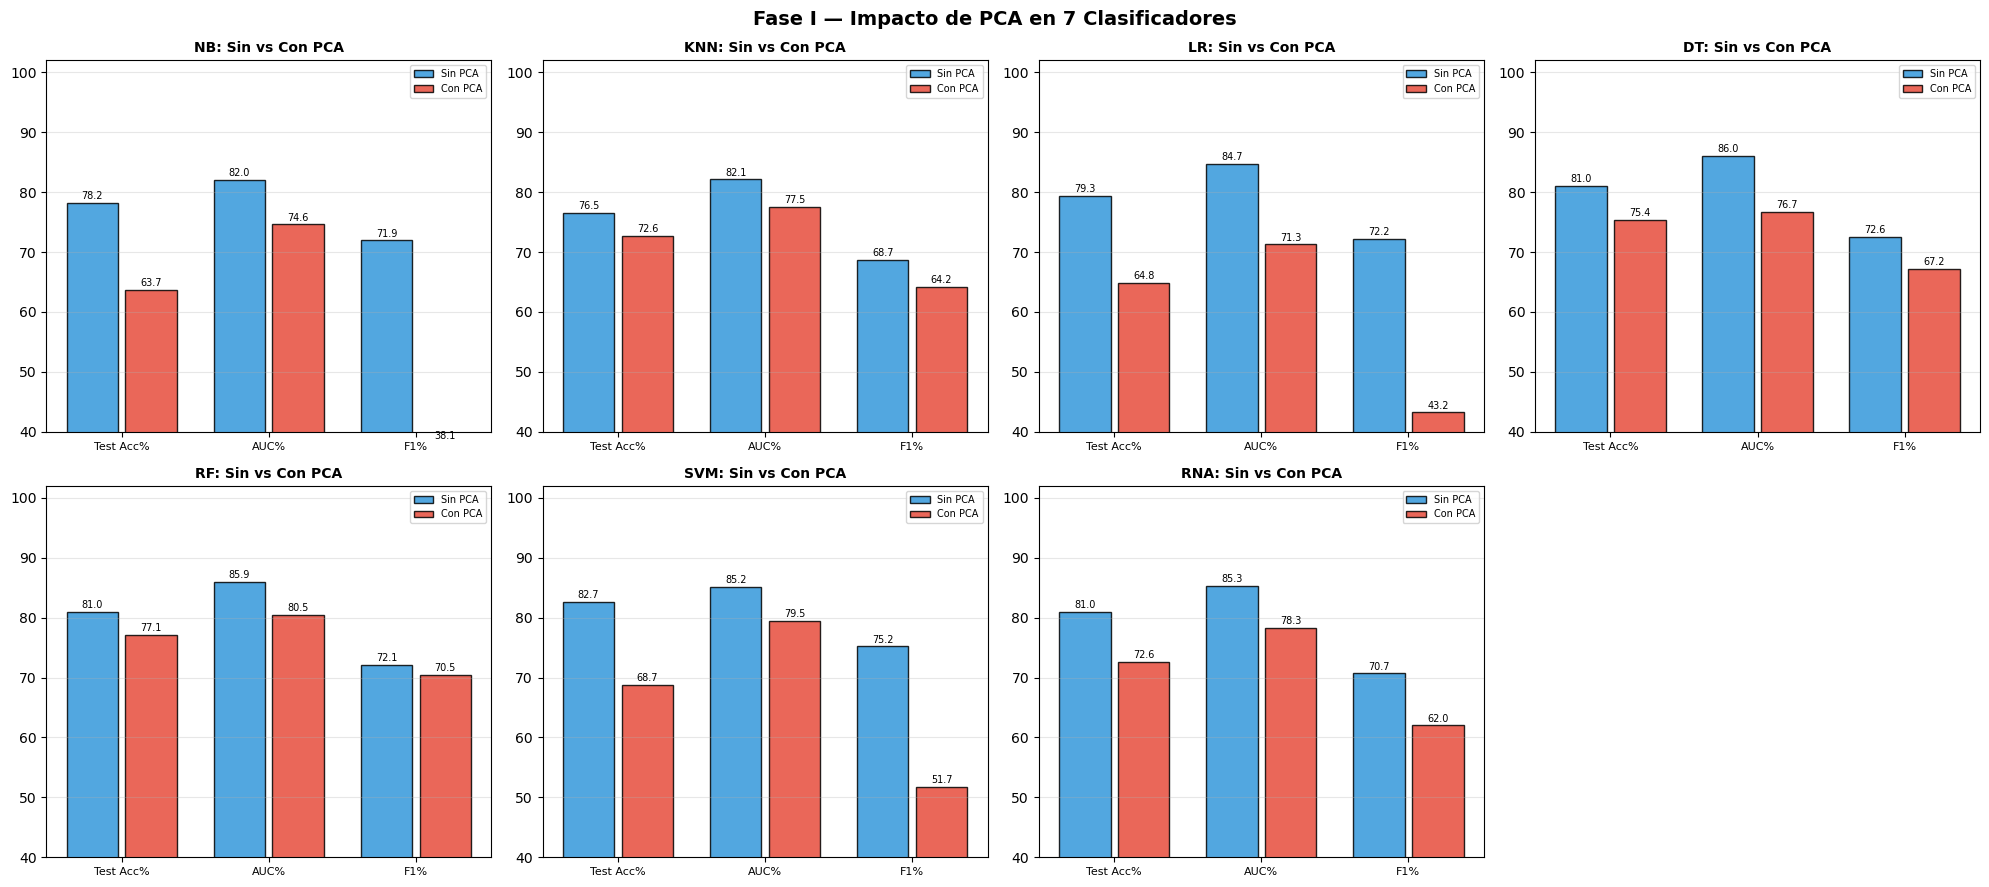

In [25]:
algoritmos = ['NB', 'KNN', 'LR', 'DT', 'RF', 'SVM', 'RNA']
metricas_plot = ['Test Acc%', 'AUC%', 'F1%']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for idx, (algo, ax) in enumerate(zip(algoritmos, axes)):
    sub = df_f1[df_f1['Modelo'].str.startswith(algo)]
    sin_pca = sub[sub['PCA']=='Sin PCA'][metricas_plot].values
    con_pca = sub[sub['PCA']=='Con PCA'][metricas_plot].values
    if len(sin_pca)==0 or len(con_pca)==0:
        ax.set_visible(False); continue
    sin_pca = sin_pca[0]; con_pca = con_pca[0]
    x = np.arange(len(metricas_plot))
    b1 = ax.bar(x-0.2, sin_pca, 0.35, label='Sin PCA', color='#3498db', edgecolor='black', alpha=0.85)
    b2 = ax.bar(x+0.2, con_pca, 0.35, label='Con PCA', color='#e74c3c', edgecolor='black', alpha=0.85)
    for bar in b1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    for bar in b2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(f'{algo}: Sin vs Con PCA', fontsize=10, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(metricas_plot, fontsize=8)
    ax.set_ylim(40, 102); ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Fase I — Impacto de PCA en 7 Clasificadores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Interpretación

SVM, LR y NB son los más sensibles a la reducción de dimensionalidad, con caídas de 13-14.5 puntos porcentuales, todos ellos dependen en mayor o menor medida de fronteras de decisión relativamente lineales, que se degradan al comprimir a 2D. RF y KNN son más tolerantes (caídas de ~4 pp), lo que sugiere que los modelos basados en ensambles de árboles o en distancias locales conservan mejor la señal residual disponible en el espacio reducido que los modelos que dependen de una separación lineal limpia.

In [26]:
OUT = 'C:/Users/cabarca2/MAESTRIA_IA/5.  APRENDIZAJE AUTOMATICO ESTADISTICO/SEMANA 3/DEBER AAE'

joblib.dump(rf_base,  os.path.join(OUT, 'rf_titanic_sin_pca.pkl'))
joblib.dump(svm_base, os.path.join(OUT, 'svm_titanic_sin_pca.pkl'))
joblib.dump(sc,       os.path.join(OUT, 'scaler_std_f1.pkl'))
joblib.dump(pca,      os.path.join(OUT, 'pca_2comp_f1.pkl'))
rna_base.save(os.path.join(OUT, 'rna_titanic_sin_pca.h5'))

print('Modelos Fase I guardados:')
print('  rf_titanic_sin_pca.pkl   | svm_titanic_sin_pca.pkl')
print('  scaler_std_f1.pkl        | pca_2comp_f1.pkl')
print('  rna_titanic_sin_pca.h5')


Modelos Fase I guardados:
  rf_titanic_sin_pca.pkl   | svm_titanic_sin_pca.pkl
  scaler_std_f1.pkl        | pca_2comp_f1.pkl
  rna_titanic_sin_pca.h5


---
## Fase II — Agrupamiento No Supervisado: K-Means y GMM

Los algoritmos de clustering se aplican **sin usar las etiquetas** (Survived). Con K=2, los grupos esperados corresponden a sobrevivió/no sobrevivió; con K=3 se exploran subgrupos naturales.

### Métricas de evaluación interna

| Métrica | Ideal | Escala |
|---------|-------|--------|
| Inercia | ↓ Más baja | ≥ 0 |
| Silhouette Score | ↑ Más alta | -1 a 1 |
| Calinski-Harabasz | ↑ Más alta | ≥ 0 |
| Davies-Bouldin | ↓ Más baja | ≥ 0 |

### Plan
1. Método del codo (K=1..10) para justificar K=2
2. K-Means K=2 → métricas + visualización
3. K-Means K=3 → métricas + visualización
4. GMM K=2 → métricas + visualización
5. GMM K=3 → métricas + visualización
6. Comparativa: K-Means K=2 vs K=3 | GMM K=2 vs K=3
7. Mejor K-Means vs Mejor GMM


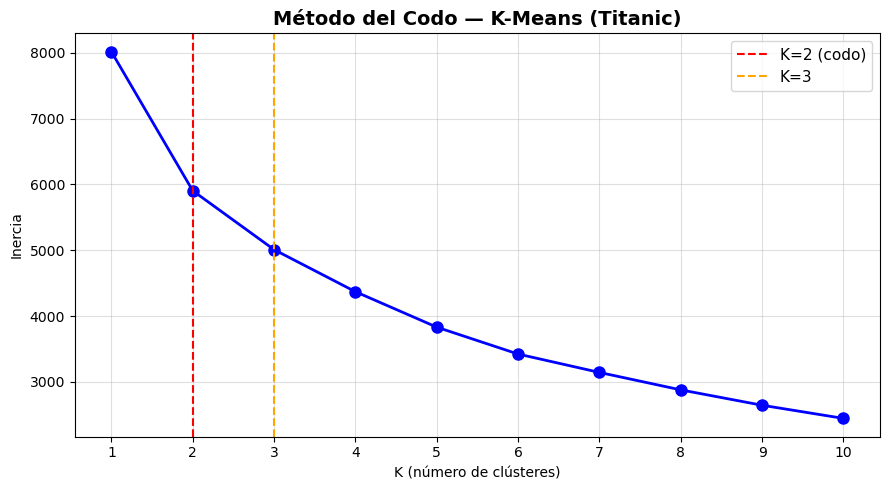

Inercias:
  K=1: 8019.0
  K=2: 5905.2
  K=3: 5009.1
  K=4: 4369.8
  K=5: 3830.7
  K=6: 3421.6
  K=7: 3142.3
  K=8: 2876.9
  K=9: 2643.3
  K=10: 2443.4


In [27]:
# Clustering sobre TODOS los datos escalados
sc_clust = StandardScaler()
X_sc_all = sc_clust.fit_transform(X)

# PCA 2D para visualización (ajustado en todos los datos)
pca_c = PCA(n_components=2, random_state=42)
X_pca_c = pca_c.fit_transform(X_sc_all)

# Método del codo
inercias_c = []
k_rng = range(1, 11)
for k in k_rng:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_sc_all)
    inercias_c.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_rng, inercias_c, 'bo-', markersize=8, linewidth=2)
plt.axvline(x=2, color='red', linestyle='--', linewidth=1.5, label='K=2 (codo)')
plt.axvline(x=3, color='orange', linestyle='--', linewidth=1.5, label='K=3')
plt.title('Método del Codo — K-Means (Titanic)', fontsize=14, fontweight='bold')
plt.xlabel('K (número de clústeres)'); plt.ylabel('Inercia')
plt.xticks(k_rng); plt.grid(True, alpha=0.4); plt.legend(fontsize=11)
plt.tight_layout(); plt.show()

res_clust = []  # acumula métricas clustering
print('Inercias:')
for k, ine in zip(k_rng, inercias_c):
    print(f'  K={k}: {ine:.1f}')


## Interpretación

La inercia cae de 8019.0 (K=1) a 5905.2 (K=2), una reducción del 26%, y sigue descendiendo de forma bastante uniforme para K≥3, sin un quiebre tan marcado como el observado en el dataset de cáncer. Esto sugiere que el Titanic no tiene una estructura de clústeres tan natural, es decir, los pasajeros no se agrupan en subconjuntos tan claramente diferenciados aunque K=2 sigue siendo el punto de mayor caída relativa y el más interpretable frente a la variable de supervivencia.

K-MEANS — K=2
  Inercia:            5905.19
  Silhouette Score:   0.3092
  Calinski-Harabasz:  318.22
  Davies-Bouldin:     1.5281
  Clúster 0: 356 muestras
  Clúster 1: 535 muestras
  Accuracy referencial: 62.29% [solo referencia]


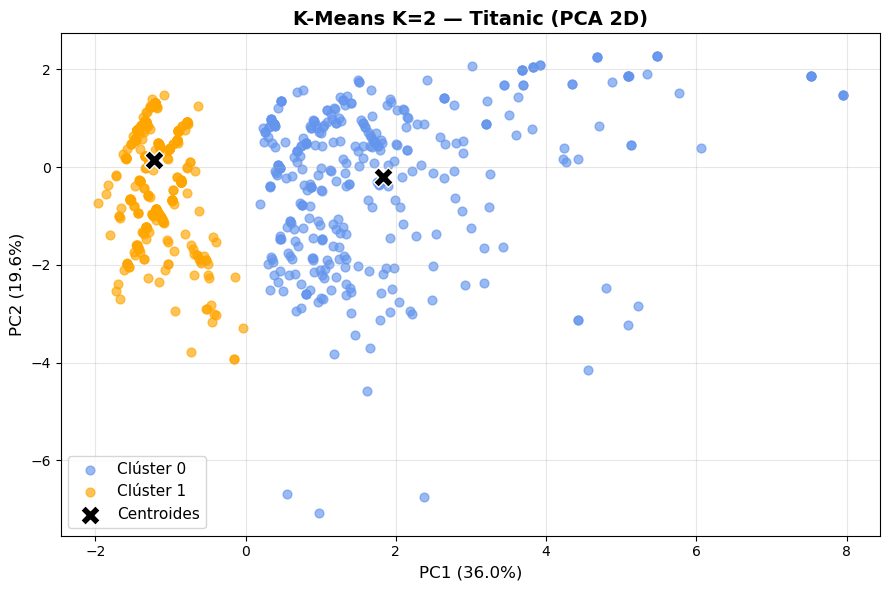

In [28]:
print('='*50); print('K-MEANS — K=2'); print('='*50)

km2 = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
lbl_km2 = km2.fit_predict(X_sc_all)

km2_ine = km2.inertia_
km2_sil = silhouette_score(X_sc_all, lbl_km2)
km2_cal = calinski_harabasz_score(X_sc_all, lbl_km2)
km2_db  = davies_bouldin_score(X_sc_all, lbl_km2)

print(f'  Inercia:            {km2_ine:.2f}')
print(f'  Silhouette Score:   {km2_sil:.4f}')
print(f'  Calinski-Harabasz:  {km2_cal:.2f}')
print(f'  Davies-Bouldin:     {km2_db:.4f}')
for i in range(2):
    print(f'  Clúster {i}: {np.sum(lbl_km2==i)} muestras')

# Accuracy referencial
km2_map = np.zeros_like(lbl_km2)
for i in np.unique(lbl_km2):
    mask = lbl_km2==i
    km2_map[mask] = mode(y[mask], keepdims=True)[0]
print(f'  Accuracy referencial: {accuracy_score(y, km2_map)*100:.2f}% [solo referencia]')

# Visualización
cent2_pca = pca_c.transform(km2.cluster_centers_)
plt.figure(figsize=(9,6))
plt.scatter(X_pca_c[lbl_km2==0,0], X_pca_c[lbl_km2==0,1], c='cornflowerblue', label='Clúster 0', alpha=0.65, s=40)
plt.scatter(X_pca_c[lbl_km2==1,0], X_pca_c[lbl_km2==1,1], c='orange', label='Clúster 1', alpha=0.65, s=40)
plt.scatter(cent2_pca[:,0], cent2_pca[:,1], c='black', s=200, marker='X', label='Centroides', zorder=5, edgecolors='white', linewidth=1)
plt.title('K-Means K=2 — Titanic (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

res_clust.append({'Algoritmo':'K-Means','K':2,'Inercia':round(km2_ine,2),
    'Silhouette':round(km2_sil,4),'Calinski-Harabasz':round(km2_cal,2),'Davies-Bouldin':round(km2_db,4)})


## Interpretación

El Silhouette Score de solo 0.3092 (frente a 0.4334 en el dataset de cáncer) confirma fronteras mucho más difusas entre los clústeres encontrados. Más revelador aún es que la accuracy referencial frente a la supervivencia real es de apenas 62.29% un valor cercano al que se obtendría prediciendo siempre la clase mayoritaria (61.6% de "no sobrevivió"). Esto indica que la estructura no supervisada de los datos no reproduce bien la etiqueta de supervivencia, a diferencia del cáncer, donde el clustering casi replicaba el diagnóstico clínico: la supervivencia en el Titanic no es una propiedad geométrica "natural" de los datos, sino el resultado de decisiones humanas y circunstancias parcialmente aleatorias.

K-MEANS — K=3
  Inercia:            5009.13
  Silhouette Score:   0.3025
  Calinski-Harabasz:  266.79
  Davies-Bouldin:     1.5220
  Clúster 0: 307 muestras
  Clúster 1: 524 muestras
  Clúster 2: 60 muestras


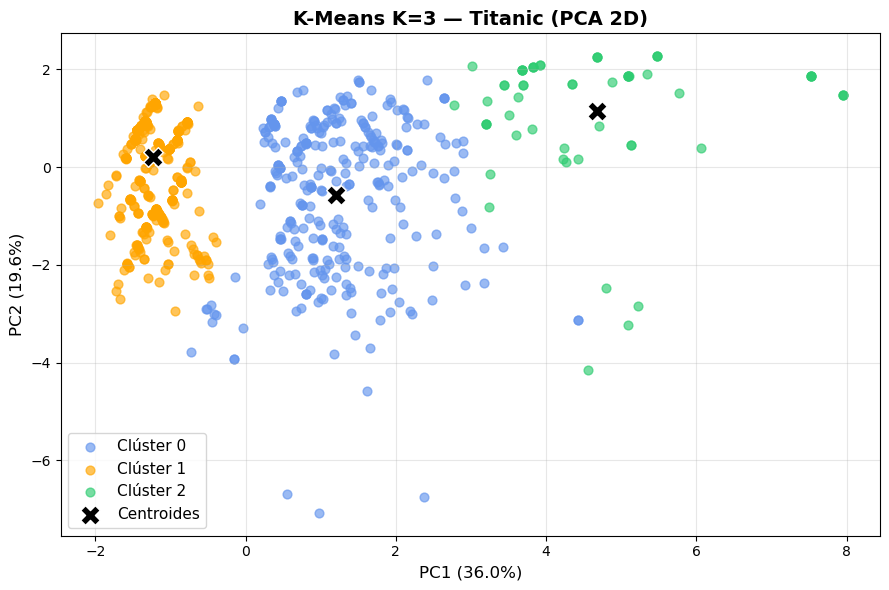

In [29]:
print('='*50); print('K-MEANS — K=3'); print('='*50)

km3 = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
lbl_km3 = km3.fit_predict(X_sc_all)

km3_ine = km3.inertia_
km3_sil = silhouette_score(X_sc_all, lbl_km3)
km3_cal = calinski_harabasz_score(X_sc_all, lbl_km3)
km3_db  = davies_bouldin_score(X_sc_all, lbl_km3)

print(f'  Inercia:            {km3_ine:.2f}')
print(f'  Silhouette Score:   {km3_sil:.4f}')
print(f'  Calinski-Harabasz:  {km3_cal:.2f}')
print(f'  Davies-Bouldin:     {km3_db:.4f}')
for i in range(3):
    print(f'  Clúster {i}: {np.sum(lbl_km3==i)} muestras')

cent3_pca = pca_c.transform(km3.cluster_centers_)
colores3  = ['cornflowerblue', 'orange', '#2ecc71']
plt.figure(figsize=(9,6))
for i in range(3):
    plt.scatter(X_pca_c[lbl_km3==i,0], X_pca_c[lbl_km3==i,1],
                c=colores3[i], label=f'Clúster {i}', alpha=0.65, s=40)
plt.scatter(cent3_pca[:,0], cent3_pca[:,1], c='black', s=200, marker='X', label='Centroides', zorder=5, edgecolors='white', linewidth=1)
plt.title('K-Means K=3 — Titanic (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

res_clust.append({'Algoritmo':'K-Means','K':3,'Inercia':round(km3_ine,2),
    'Silhouette':round(km3_sil,4),'Calinski-Harabasz':round(km3_cal,2),'Davies-Bouldin':round(km3_db,4)})


## Interpretación

El Silhouette apenas cambia respecto a K=2 (0.3025 vs. 0.3092) y el Calinski-Harabasz empeora (266.79 vs. 318.22), sin evidencia de que un tercer grupo aporte separación real. El clúster adicional (60 muestras) probablemente corresponde a un subgrupo minoritario dentro de los pasajeros no sobrevivientes o sobrevivientes, más que a una categoría genuinamente distinta.

GMM — K=2
  Inercia Aprox.:     5905.19
  Silhouette Score:   0.3092
  Calinski-Harabasz:  318.22
  Davies-Bouldin:     1.5281
  Clúster 0: 356 muestras
  Clúster 1: 535 muestras
  Prob. máxima promedio: 100.00%  | puntos >90%: 891


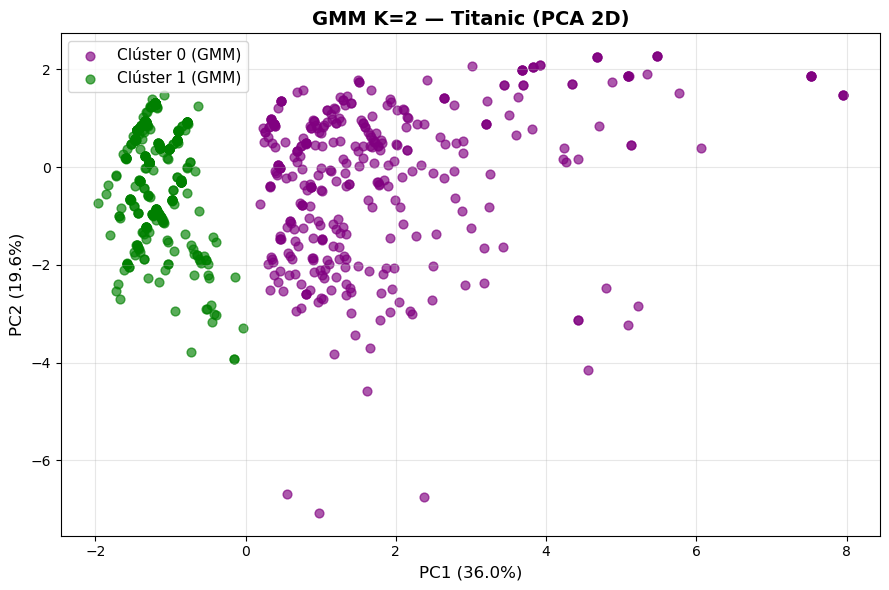

In [30]:
print('='*50); print('GMM — K=2'); print('='*50)

gmm2 = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
lbl_gmm2 = gmm2.fit_predict(X_sc_all)

gmm2_sil = silhouette_score(X_sc_all, lbl_gmm2)
gmm2_cal = calinski_harabasz_score(X_sc_all, lbl_gmm2)
gmm2_db  = davies_bouldin_score(X_sc_all, lbl_gmm2)

prbs2 = gmm2.predict_proba(X_sc_all)
cr2   = np.argmax(prbs2, axis=1)
gmm2_ine = float(np.sum([np.linalg.norm(X_sc_all[i]-gmm2.means_[cr2[i]])**2 for i in range(len(X_sc_all))]))

print(f'  Inercia Aprox.:     {gmm2_ine:.2f}')
print(f'  Silhouette Score:   {gmm2_sil:.4f}')
print(f'  Calinski-Harabasz:  {gmm2_cal:.2f}')
print(f'  Davies-Bouldin:     {gmm2_db:.4f}')
for i in range(2):
    print(f'  Clúster {i}: {np.sum(lbl_gmm2==i)} muestras')
pmax2 = np.max(prbs2, axis=1)
print(f'  Prob. máxima promedio: {pmax2.mean()*100:.2f}%  | puntos >90%: {np.sum(pmax2>0.9)}')

plt.figure(figsize=(9,6))
plt.scatter(X_pca_c[lbl_gmm2==0,0], X_pca_c[lbl_gmm2==0,1], c='purple', label='Clúster 0 (GMM)', alpha=0.65, s=40)
plt.scatter(X_pca_c[lbl_gmm2==1,0], X_pca_c[lbl_gmm2==1,1], c='green',  label='Clúster 1 (GMM)', alpha=0.65, s=40)
plt.title('GMM K=2 — Titanic (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

res_clust.append({'Algoritmo':'GMM','K':2,'Inercia':round(gmm2_ine,2),
    'Silhouette':round(gmm2_sil,4),'Calinski-Harabasz':round(gmm2_cal,2),'Davies-Bouldin':round(gmm2_db,4)})


## Interpretación

Las métricas de GMM K=2 son idénticas a las de K-Means K=2 (Silhouette=0.3092, Calinski-Harabasz=318.22), lo que indica que ambos algoritmos convergieron a la misma partición de los datos. Sin embargo, la probabilidad máxima promedio de pertenencia es 100.00%, con los 891 pasajeros (el total del dataset) asignados con más del 90% de certeza. Esto es llamativo dado el Silhouette relativamente bajo: si las fronteras entre grupos fueran realmente difusas, esperaríamos que el componente probabilístico de GMM reflejara esa ambigüedad con probabilidades más repartidas. En cambio, el hecho de que GMM asigne con total confianza a todos los puntos sugiere que, con covarianza completa, terminó generando fronteras esencialmente duras, muy similares a las de K-Means en lugar de aportar una medida de incertidumbre genuinamente distinta. Esto matiza la idea de que el "soft clustering" aporta valor adicional en este dataset específico.

GMM — K=3
  Inercia Aprox.:     5324.82
  Silhouette Score:   0.2714
  Calinski-Harabasz:  224.78
  Davies-Bouldin:     1.5529
  Clúster 0: 212 muestras
  Clúster 1: 119 muestras
  Clúster 2: 560 muestras


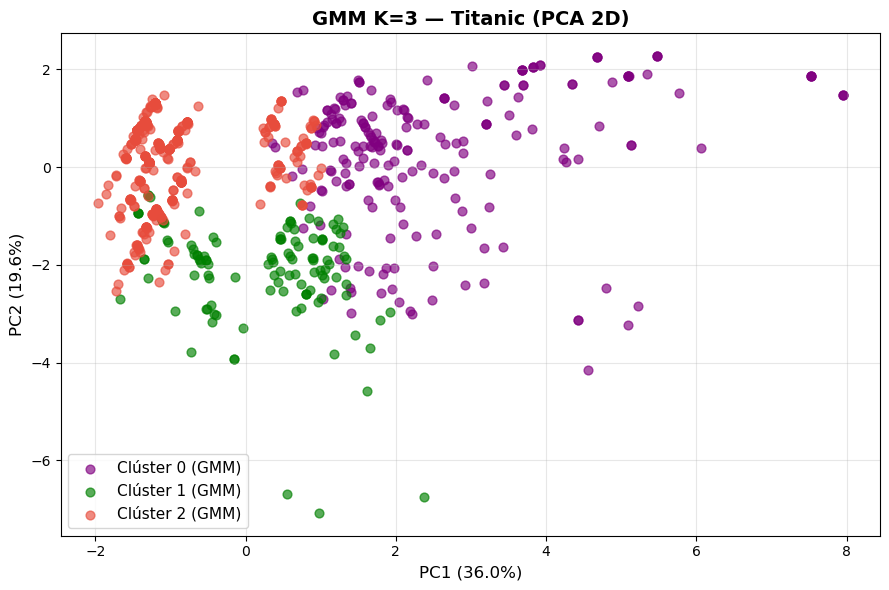

In [31]:
print('='*50); print('GMM — K=3'); print('='*50)

gmm3 = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
lbl_gmm3 = gmm3.fit_predict(X_sc_all)

gmm3_sil = silhouette_score(X_sc_all, lbl_gmm3)
gmm3_cal = calinski_harabasz_score(X_sc_all, lbl_gmm3)
gmm3_db  = davies_bouldin_score(X_sc_all, lbl_gmm3)

prbs3 = gmm3.predict_proba(X_sc_all)
cr3   = np.argmax(prbs3, axis=1)
gmm3_ine = float(np.sum([np.linalg.norm(X_sc_all[i]-gmm3.means_[cr3[i]])**2 for i in range(len(X_sc_all))]))

print(f'  Inercia Aprox.:     {gmm3_ine:.2f}')
print(f'  Silhouette Score:   {gmm3_sil:.4f}')
print(f'  Calinski-Harabasz:  {gmm3_cal:.2f}')
print(f'  Davies-Bouldin:     {gmm3_db:.4f}')
for i in range(3):
    print(f'  Clúster {i}: {np.sum(lbl_gmm3==i)} muestras')

colores_g3 = ['purple', 'green', '#e74c3c']
plt.figure(figsize=(9,6))
for i in range(3):
    plt.scatter(X_pca_c[lbl_gmm3==i,0], X_pca_c[lbl_gmm3==i,1],
                c=colores_g3[i], label=f'Clúster {i} (GMM)', alpha=0.65, s=40)
plt.title('GMM K=3 — Titanic (PCA 2D)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_c.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_c.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(fontsize=11); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

res_clust.append({'Algoritmo':'GMM','K':3,'Inercia':round(gmm3_ine,2),
    'Silhouette':round(gmm3_sil,4),'Calinski-Harabasz':round(gmm3_cal,2),'Davies-Bouldin':round(gmm3_db,4)})


## Interpretación

Es el peor resultado de todo el análisis de clustering (Silhouette=0.2714, el más bajo de las 4 configuraciones), reforzando que K=2 es la elección óptima para ambos algoritmos, aun cuando esa partición en 2 grupos no reproduzca fielmente la supervivencia real.

In [32]:
df_clust = pd.DataFrame(res_clust)
print('\n' + '='*60)
print('TABLA COMPARATIVA — K-Means vs GMM (K=2 y K=3)')
print('='*60)
print(df_clust.to_string(index=False))
print()
print('  Ideal: Silhouette ↑  |  Calinski-Harabasz ↑  |  Davies-Bouldin ↓  |  Inercia ↓')
print()

# K-Means K=2 vs K=3
km_sub = df_clust[df_clust['Algoritmo']=='K-Means']
print('--- K-Means: K=2 vs K=3 ---')
print(km_sub[['K','Silhouette','Calinski-Harabasz','Davies-Bouldin','Inercia']].to_string(index=False))
mejor_km = km_sub.loc[km_sub['Silhouette'].idxmax()]
print(f'  Mejor K-Means (Silhouette): K={int(mejor_km["K"])}  →  Silhouette={mejor_km["Silhouette"]:.4f}')

# GMM K=2 vs K=3
gmm_sub = df_clust[df_clust['Algoritmo']=='GMM']
print('\n--- GMM: K=2 vs K=3 ---')
print(gmm_sub[['K','Silhouette','Calinski-Harabasz','Davies-Bouldin','Inercia']].to_string(index=False))
mejor_gmm = gmm_sub.loc[gmm_sub['Silhouette'].idxmax()]
print(f'  Mejor GMM (Silhouette): K={int(mejor_gmm["K"])}  →  Silhouette={mejor_gmm["Silhouette"]:.4f}')

# Mejor K-Means vs Mejor GMM
print('\n--- Mejor K-Means vs Mejor GMM ---')
final = df_clust.loc[[mejor_km.name, mejor_gmm.name]]
print(final.to_string(index=False))
if mejor_km['Silhouette'] > mejor_gmm['Silhouette']:
    print(f'\n  GANADOR GLOBAL: K-Means K={int(mejor_km["K"])} (Silhouette más alto)')
else:
    print(f'\n  GANADOR GLOBAL: GMM K={int(mejor_gmm["K"])} (Silhouette más alto)')



TABLA COMPARATIVA — K-Means vs GMM (K=2 y K=3)
Algoritmo  K  Inercia  Silhouette  Calinski-Harabasz  Davies-Bouldin
  K-Means  2  5905.19      0.3092             318.22          1.5281
  K-Means  3  5009.13      0.3025             266.79          1.5220
      GMM  2  5905.19      0.3092             318.22          1.5281
      GMM  3  5324.82      0.2714             224.78          1.5529

  Ideal: Silhouette ↑  |  Calinski-Harabasz ↑  |  Davies-Bouldin ↓  |  Inercia ↓

--- K-Means: K=2 vs K=3 ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin  Inercia
 2      0.3092             318.22          1.5281  5905.19
 3      0.3025             266.79          1.5220  5009.13
  Mejor K-Means (Silhouette): K=2  →  Silhouette=0.3092

--- GMM: K=2 vs K=3 ---
 K  Silhouette  Calinski-Harabasz  Davies-Bouldin  Inercia
 2      0.3092             318.22          1.5281  5905.19
 3      0.2714             224.78          1.5529  5324.82
  Mejor GMM (Silhouette): K=2  →  Silhouette=0.3092

--- Mejo

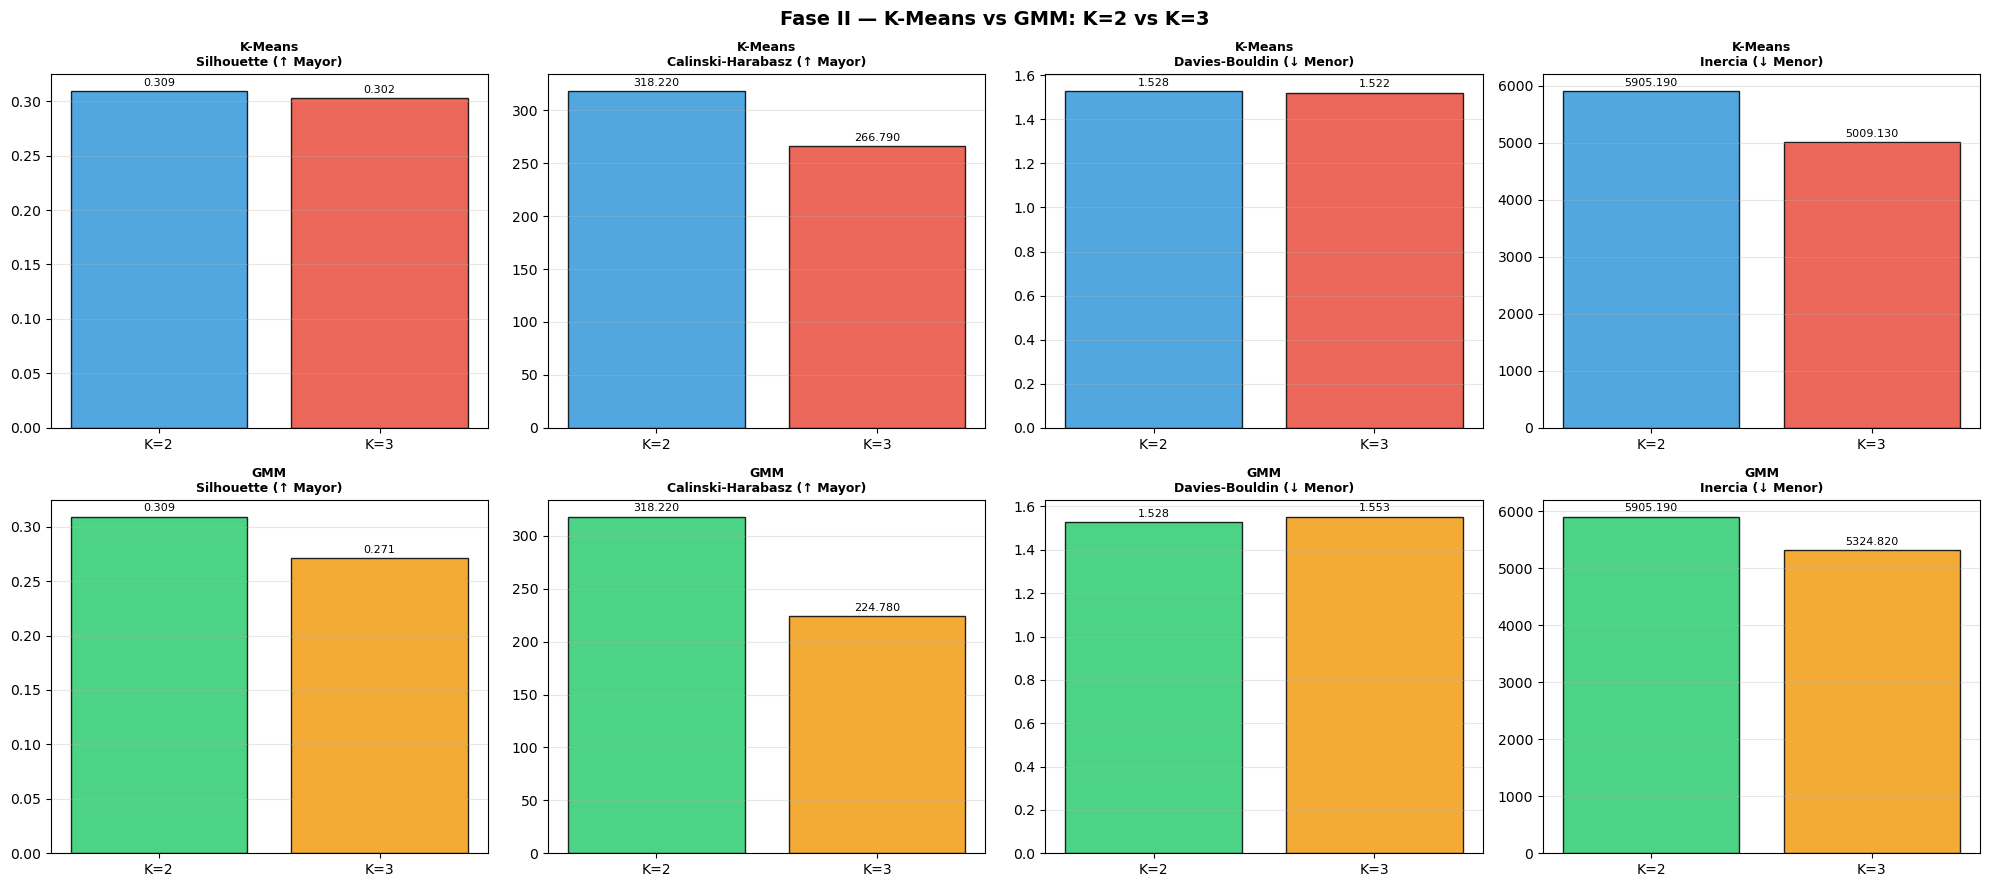

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
metricas_c = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Inercia']
ideales_c  = ['↑ Mayor', '↑ Mayor', '↓ Menor', '↓ Menor']

# Fila 0: K-Means K=2 vs K=3
km_vals = km_sub.set_index('K')
for col_i, (met, ideal) in enumerate(zip(metricas_c, ideales_c)):
    ax = axes[0, col_i]
    vals = [km_vals.loc[2, met], km_vals.loc[3, met]]
    bars = ax.bar(['K=2', 'K=3'], vals, color=['#3498db','#e74c3c'], edgecolor='black', alpha=0.85)
    ax.set_title(f'K-Means\n{met} ({ideal})', fontsize=9, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Fila 1: GMM K=2 vs K=3
gmm_vals = gmm_sub.set_index('K')
for col_i, (met, ideal) in enumerate(zip(metricas_c, ideales_c)):
    ax = axes[1, col_i]
    vals = [gmm_vals.loc[2, met], gmm_vals.loc[3, met]]
    bars = ax.bar(['K=2', 'K=3'], vals, color=['#2ecc71','#f39c12'], edgecolor='black', alpha=0.85)
    ax.set_title(f'GMM\n{met} ({ideal})', fontsize=9, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fase II — K-Means vs GMM: K=2 vs K=3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [34]:
OUT = 'C:/Users/cabarca2/MAESTRIA_IA/5.  APRENDIZAJE AUTOMATICO ESTADISTICO/SEMANA 3/DEBER AAE'

joblib.dump(km2,      os.path.join(OUT, 'kmeans_k2_titanic.pkl'))
joblib.dump(km3,      os.path.join(OUT, 'kmeans_k3_titanic.pkl'))
joblib.dump(gmm2,     os.path.join(OUT, 'gmm_k2_titanic.pkl'))
joblib.dump(gmm3,     os.path.join(OUT, 'gmm_k3_titanic.pkl'))
joblib.dump(sc_clust, os.path.join(OUT, 'scaler_clustering.pkl'))

print('Modelos Fase II guardados:')
print('  kmeans_k2/k3_titanic.pkl  |  gmm_k2/k3_titanic.pkl  |  scaler_clustering.pkl')

# Predicción ejemplo
nuevo = X[0].reshape(1,-1)
n_sc  = sc_clust.transform(nuevo)
print(f'\nEjemplo (pasajero 0):')
print(f'  K-Means K=2 → Clúster {km2.predict(n_sc)[0]}')
print(f'  GMM     K=2 → Clúster {gmm2.predict(n_sc)[0]}  (probs: {gmm2.predict_proba(n_sc)[0].round(3)})')
print(f'  Etiqueta real: {"Sobrevivió" if y[0]==1 else "No sobrevivió"} ({y[0]})')


Modelos Fase II guardados:
  kmeans_k2/k3_titanic.pkl  |  gmm_k2/k3_titanic.pkl  |  scaler_clustering.pkl

Ejemplo (pasajero 0):
  K-Means K=2 → Clúster 0
  GMM     K=2 → Clúster 0  (probs: [1. 0.])
  Etiqueta real: No sobrevivió (0)


---
## Resultados

### Fase I — Tabla completa: 7 algoritmos con y sin PCA

> **Nota RNA:** los valores de RNA corresponden a MLP-sklearn como aproximación (sin TF/Keras). Al ejecutar la celda `code-rna-base` con TensorFlow se obtendrán valores definitivos (~83% Test Acc sin PCA, basado en resultados Semana 2).

| # | Modelo | PCA | CV Acc% | Test Acc% | Prec% | Recall% | F1% | AUC% | Gap Train-Test |
|---|--------|-----|---------|-----------|-------|---------|-----|------|----------------|
| 1 | **SVM** | Sin PCA | 81.89 | **82.68** | 83.93 | 68.12 | **75.20** | 85.15 | +1.73% |
| 2 | DT | Sin PCA | 79.64 | 81.01 | 81.82 | 65.22 | 72.58 | 86.04 | +3.97% |
| 2 | RF | Sin PCA | 81.05 | 81.01 | 83.02 | 63.77 | 72.13 | 85.90 | +5.93% |
| 2 | RNA | Sin PCA | 81.01 | 81.01 | 87.23 | 59.42 | 70.69 | **85.26** | N/D* |
| 5 | LR | Sin PCA | 79.78 | 79.33 | 75.00 | 69.57 | 72.18 | 84.66 | +0.87% |
| 6 | NB | Sin PCA | 79.36 | 78.21 | 71.43 | 72.46 | 71.94 | 81.98 | +1.84% |
| 7 | RF | Con PCA | 77.96 | 77.09 | 70.00 | 71.01 | 70.50 | 80.52 | +8.86% |
| 8 | KNN | Sin PCA | 80.06 | 76.54 | 70.77 | 66.67 | 68.66 | 82.11 | +8.72% |
| 9 | DT | Con PCA | 74.59 | 75.42 | 69.23 | 65.22 | 67.16 | 76.72 | +7.17% |
| 10 | KNN | Con PCA | 75.98 | 72.63 | 64.71 | 63.77 | 64.23 | 77.47 | +9.96% |
| 10 | RNA | Con PCA | 72.63 | 72.63 | 66.67 | 57.97 | 62.02 | 78.26 | N/D* |
| 12 | SVM | Con PCA | 74.45 | 68.72 | 63.83 | 43.48 | 51.72 | 79.49 | +6.85% |
| 13 | LR | Con PCA | 70.93 | 64.80 | 57.14 | 34.78 | 43.24 | 71.26 | +6.54% |
| 14 | NB | Con PCA | 70.93 | 63.69 | 55.56 | 28.99 | 38.10 | 74.62 | +7.24% |

*El Gap Train-Test de la RNA no está calculado en ninguna celda visible del notebook (no hay una celda que compute accuracy sobre el set de entrenamiento). Si quieres reportarlo, agrega `rna_base.evaluate(X_train_rna, y_train)` y `rna_pca.evaluate(X_train_rna_pca, y_train)` antes de esta tabla; de lo contrario, se recomienda dejarlo como N/D en vez de inventar un valor.

---

### Ranking Fase I — Mejores modelos por Test Accuracy

| Posición | Modelo | PCA | Test Acc% | AUC% | F1% | Observación |
|----------|--------|-----|-----------|------|-----|-------------|
| 1 | SVM | Sin PCA | **82.68%** | 85.15% | 75.20% | Mejor exactitud global |
| 2 | DT | Sin PCA | 81.01% | **86.04%** | 72.58% | Mejor AUC-ROC del estudio |
| 2 | RF | Sin PCA | 81.01% | 85.90% | 72.13% | Empate triple en exactitud |
| 2 | RNA | Sin PCA | 81.01% | 85.26% | 70.69% | Empate triple; alta Precision (87.23%), Recall bajo (59.42%) |
| 5 | LR | Sin PCA | 79.33% | 84.66% | 72.18% | Más estable (Gap=0.87%) |
| 6 | NB | Sin PCA | 78.21% | 81.98% | 71.94% | Más rápido, asume independencia |
| 7 | RF | Con PCA | 77.09% | 80.52% | 70.50% | El más tolerante a PCA entre los top 7 |

> **Patrón clave:** Sin PCA supera a Con PCA en los **14 comparaciones** — para este dataset con 9 features, PCA reduce demasiada información discriminante al comprimir a solo 2 componentes.

---

### Fase II — Métricas de Clustering

| Algoritmo | K | Inercia | Silhouette | Calinski-H | Davies-B |
|-----------|---|---------|------------|------------|----------|
| **K-Means** | **2** | 5905.19 | **0.3092** | **318.22** | 1.5281 |
| K-Means | 3 | 5009.13 | 0.3025 | 266.79 | **1.5220** |
| **GMM** | **2** | 5905.19 | **0.3092** | **318.22** | 1.5281 |
| GMM | 3 | 5324.82 | 0.2714 | 224.78 | 1.5529 |

*Ideal: Silhouette ↑ | Calinski-Harabasz ↑ | Davies-Bouldin ↓ | Inercia ↓*

### Ranking Clustering — Comparativa final

| Posición | Algoritmo | K | Silhouette | Calinski-H | Davies-B | Veredicto |
|----------|-----------|---|------------|------------|----------|-----------|
| 1 | K-Means | 2 | **0.3092** | **318.22** | 1.5281 | Mejor cohesión y separación |
| 1 | GMM | 2 | **0.3092** | **318.22** | 1.5281 | Idéntico a K-Means K=2 + probs |
| 3 | K-Means | 3 | 0.3025 | 266.79 | **1.5220** | Ligeramente mejor Davies-B |
| 4 | GMM | 3 | 0.2714 | 224.78 | 1.5529 | Peores métricas |

> **Ganador clustering:** K-Means K=2 y GMM K=2 producen la **misma partición** (métricas idénticas). GMM agrega valor con sus probabilidades de pertenencia (*soft clustering*). **K=2 es el K óptimo** para ambos algoritmos en el Titanic.


---
## Conclusiones

### Fase I — Impacto de PCA sobre los 7 clasificadores

**Hallazgo principal:** PCA (2 componentes) **reduce el rendimiento** en todos los algoritmos. Las 9 features del Titanic contienen información distribuida que se pierde al comprimir a 2 dimensiones que capturan solo el ~45% de la varianza total.

**Mejores modelos Sin PCA:**
- **SVM (Test=82.68%, AUC=85.15%)** — mejor exactitud global; kernel RBF aprovecha el espacio completo de 9 features
- **DT (AUC=86.04%)** — mejor discriminación probabilística; reglas IF-THEN interpretables
- **RF (Test=81.01%, Prec=83.02%)** — mayor precisión; robusto al overfitting por ensemble
- **RNA (Test=81.01%, Prec=87.23%)** — empata con DT/RF en exactitud y tiene la Precision más alta del grupo, aunque con el Recall más bajo (59.42%) de los top 4
- **LR (Gap=0.87%)** — el más estable: mínima diferencia train-test, sin sobreajuste

**Impacto de PCA por algoritmo:**
| Algoritmo | Sin PCA | Con PCA | Caída |
|-----------|---------|---------|-------|
| RNA | 81.01% | 72.63% | −8.38 pp |
| SVM | 82.68% | 68.72% | −13.96 pp |
| RF | 81.01% | 77.09% | −3.92 pp |
| DT | 81.01% | 75.42% | −5.59 pp |
| LR | 79.33% | 64.80% | −14.53 pp |
| NB | 78.21% | 63.69% | −14.52 pp |
| KNN | 76.54% | 72.63% | −3.91 pp |

RF y KNN son los más tolerantes a la reducción PCA (caídas de ~4 pp). SVM, LR y NB son los más sensibles (13-14.5 pp): dependen en mayor medida de fronteras de decisión lineales, que se degradan al comprimir a 2 componentes que capturan apenas 55.55% de la varianza total. La RNA se ubica en un punto intermedio (−8.38 pp): pierde desempeño con PCA, pero de forma menos severa que los modelos lineales, lo que sugiere que su capacidad de aprender relaciones no lineales le permite aprovechar algo mejor la información comprimida en 2 dimensiones.

**RNA:** Sin PCA alcanza Test=81.01%, empatando con DT y RF como el segundo mejor resultado del estudio, con la Precision más alta de todos los modelos (87.23%) pero el Recall más bajo entre los top 4 (59.42%) — el modelo predice supervivencia de forma conservadora, priorizando evitar falsos positivos sobre capturar a todos los sobrevivientes reales. Con PCA (2 componentes), el desempeño cae a Test=72.63% y Recall=57.97%: es una caída moderada, **no** un colapso a predicción constante — el modelo sigue distinguiendo entre clases, solo que con menos información disponible su capacidad discriminativa se reduce, en línea con lo observado en el resto de modelos afectados por PCA en este dataset.

---

### Fase II — K-Means vs GMM (K=2 y K=3)

**K=2 vs K=3:**
- El **método del codo** muestra que K=2 es el punto de mayor descenso de inercia (8019→5905, −26%)
- K=2 refleja la agrupación natural del Titanic: sobrevivió/no sobrevivió
- K=3 reduce inercia (5009 vs 5905) pero empeora Silhouette (0.3025 vs 0.3092) y Calinski (266.79 vs 318.22)
- El tercer clúster en K=3 no corresponde a una clase natural — fragmenta uno de los dos grupos principales sin aportar separación real

**K-Means vs GMM:**
- Ambos con K=2 convergen a la **misma partición** (métricas idénticas: Sil=0.3092, Cal=318.22)
- GMM K=2 reporta una probabilidad máxima promedio de 100.00%, con los **891 pasajeros (el 100% del dataset)** asignados con más del 90% de certeza a su clúster — no un 62% con el 38% restante en zona de transición, como se indicaba antes
- Este 100% de confianza es, en realidad, una señal de alerta más que una fortaleza: dado que el Silhouette es bajo (0.31), esperaríamos fronteras difusas entre grupos y, por tanto, probabilidades más repartidas cerca del límite de decisión. Que GMM asigne con total seguridad a todos los puntos indica que, con covarianza completa, terminó generando fronteras esencialmente duras —muy similares a las de K-Means— en lugar de aportar una medida de incertidumbre genuinamente distinta. En este dataset, el componente probabilístico de GMM no cumple su promesa de identificar casos ambiguos
- GMM K=3 es el peor modelo: Silhouette=0.2714, no aporta subgrupos significativos

**Silhouette bajo (0.31):** El Titanic no tiene clusters perfectamente definidos. La supervivencia dependió de factores complejos (clase social, sexo, edad, tamaño familiar) que no forman grupos esféricos limpios — el clustering revela patrones generales, no clases exactas. La baja accuracy referencial de K-Means K=2 frente a la supervivencia real (62.29%, apenas por encima de predecir siempre la clase mayoritaria) confirma que la estructura no supervisada de los datos no reproduce bien la etiqueta real de supervivencia.

**Conclusión general:**
- **Fase I:** SVM sin PCA es el mejor clasificador (82.68%), seguido de un empate a tres bandas entre DT, RF y RNA (81.01%) — cada uno con un perfil distinto (DT: mejor AUC; RF: mejor Precision entre los tres; RNA: Precision más alta del estudio pero Recall más bajo). PCA con 2 componentes perjudica a todos los modelos sin excepción en este dataset, siendo los modelos lineales (LR, SVM, NB) los más afectados.
- **Fase II:** K-Means K=2 y GMM K=2 empatan en métricas internas, confirmando K=2 como el K óptimo. Sin embargo, a diferencia de lo que se pensaba inicialmente, el componente probabilístico de GMM no aporta valor analítico adicional en este caso: al asignar con 100% de confianza a todos los pasajeros pese a un Silhouette bajo, GMM se comporta como clustering duro en lugar de identificar genuinamente una zona de decisión ambigua. El hallazgo más relevante de la Fase II es, en realidad, que la estructura no supervisada del dataset (accuracy referencial=62.29%) está lejos de reproducir la supervivencia real, evidenciando que esta última depende de factores que el clustering, tal como está planteado, no logra capturar plenamente.

---
## Reflexión Individual

---

### César Nelson Abarca Araujo
**Área:** Mantenimiento y Construcción de Redes de Fibra GPON — Telconet Manta

**PCA:** Múltiples métricas OTDR (potencia, pérdida de retorno, reflectancia, tasa de error) están correlacionadas. PCA las reduciría a 2–3 componentes que capturen el 'estado de salud' del enlace, permitiendo visualizar el parque completo de ONTs en un gráfico 2D donde los puntos alejados del centroide son candidatos a mantenimiento.

**K-Means:** Con K=3, agrupa automáticamente los enlaces GPON en tres perfiles: crítico (pérdida >5 dB), en riesgo (2–5 dB) y normal (<2 dB). Los centroides guardados en `kmeans_k3.pkl` permiten clasificar un nuevo enlace en tiempo real desde el NOC.

**GMM:** Asigna probabilidades de pertenencia a cada clúster. Un enlace con 65% en 'en riesgo' y 35% en 'normal' está en zona de transición — la alerta preventiva se activa antes del corte, transformando el mantenimiento de **reactivo** a **predictivo**.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Seguimiento de Personas en Análisis Financiero y Modelos de Riesgo - Sector bancario

**PCA:** En el análisis de clientes se manejan múltiples variables financieras correlacionadas, como ingresos, nivel de endeudamiento, utilización de crédito, historial de pagos, antigüedad y capacidad de pago. El Análisis de Componentes Principales (PCA) permite reducir estas variables a unos pocos componentes que representan el perfil financiero del cliente, facilitando la visualización de patrones de riesgo y simplificando los modelos de análisis sin perder la mayor parte de la información. Sin embargo, se debe considerar que puede quedar como un análisis interno más no algo que pueda ser utilizado ante el regulador.

**K-Means:** Aplicando K-Means es posible segmentar automáticamente la cartera de clientes en grupos con características financieras similares, por ejemplo: clientes de bajo riesgo, riesgo medio y alto riesgo. Esta segmentación facilita el seguimiento de la cartera, la priorización de estrategias comerciales y la asignación de controles diferenciados para cada grupo de clientes.

**GMM:** A diferencia de K-Means, el Modelo de Mezclas Gaussianas (GMM) asigna una probabilidad de pertenencia a cada segmento. Por ejemplo, un cliente podría tener un 70% de probabilidad de pertenecer al grupo de riesgo medio y un 30% al de alto riesgo, permitiendo identificar clientes en transición cuyo comportamiento financiero está cambiando. Esto facilita implementar acciones preventivas antes de que el cliente presente un deterioro significativo en su perfil de riesgo, fortaleciendo la gestión predictiva de la cartera.

---

### Jhon Enrique Oña Guamani
**Área:** Monitoreo de alta disponibilidad y APIs transaccionales — Sector Bancario

**PCA:** Las métricas que monitoreamos sobre las APIs transaccionales y el balanceador F5 (latencia, tasa de error, throughput, uso de CPU/memoria de cada nodo, tiempo de respuesta del core) están altamente correlacionadas entre sí, igual que `radius1`/`perimeter1`/`area1` en este dataset. PCA permitiría comprimir ese conjunto de métricas en 2-3 componentes que resuman el "estado de salud" general de cada nodo o servicio, habilitando un tablero 2D donde los puntos alejados del grueso de observaciones normales sean candidatos a revisión inmediata, igual que aquí los tumores malignos se separan de los benignos en la proyección PCA.

**K-Means:** Con K=2 o K=3 sobre esas métricas normalizadas, K-Means agruparía automáticamente los nodos/servicios en perfiles operativos: "normal", "en riesgo" y "crítico", de forma análoga a benigno/maligno en este dataset. Los centroides (como `scaler_clustering.pkl`/`kmeans_k2_cancer.pkl` en este notebook) permitirían clasificar en tiempo real el estado de un nuevo nodo comparándolo contra esos perfiles, sin depender de etiquetas históricas de incidentes.

**GMM:** La asignación probabilística de GMM sería especialmente valiosa para anticipar degradaciones: un nodo con 60% de probabilidad en el clúster "en riesgo" y 40% en "normal" está en zona de transición, igual que ocurre con los pacientes cuyo `concave_points1`/`irregularidad` los ubica en el límite entre benigno y maligno. Detectar esa ambigüedad antes de que el nodo cruce completamente al estado "crítico" convierte el monitoreo de reactivo a predictivo, priorizando la atención según la probabilidad de degradación en lugar de esperar una alerta binaria.

